# Hurricane Helene — GWR / Moran's I (comparable pipeline)

**Unit of analysis:** 38 income × NCHS spatially-constrained clusters.

Helene's footprint is the southern-Appalachian arc (TN/NC/GA/SC/VA); because the affected area spans hundreds of small counties, the unit of analysis is **38 spatially-constrained clusters** (counties grouped within each NCHS urban–rural code so each cluster is contiguous and income-coherent).

**Pipeline (identical for both storms):** global OLS → Moran's I on residuals (the *should-we-GWR* gate) → Geographically Weighted Regression → matched maps and an OLS-vs-GWR model comparison.

> **Comparability.** This notebook and its sibling [`milton_gwr_compare.ipynb`](milton_gwr_compare.ipynb) (Hurricane Milton) run the **identical** pipeline from the shared module `gwr_compare_utils.py`: same pooled dataset, same four predictors (median HH income, %White, NCHS urban–rural code, distance-to-track), same two within-county DVs, same spatial weights, and **figures with matched colour scales and layouts** — so Fig _n_ here is directly comparable to Fig _n_ there. All outputs are written to `results/gwr_compare/helene/`.

In [1]:
%matplotlib inline
import importlib
import gwr_compare_utils as U
importlib.reload(U)               # pick up edits to the shared module
import pandas as pd
pd.set_option('display.width', 140)

HURR = 'helene'
print('Features :', U.FEATURES)
print('DVs      :', [d[1] for d in U.DVS])

Features : ['median_household_income', 'pct_white', 'nchs_code', 'dist_to_track_mi']
DVs      : ['Largest Drop — Within (%)', 'Recovery Time — Within (days)']


/Users/qing/miniconda3/envs/geo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## §1  Load data & reconstruct geometry
Pulls this storm's rows from `pooled_dataset.csv`, attaches the unit polygons (Helene: dissolve counties→clusters; Milton: the 21 counties), projects to Albers (EPSG:5070), and z-scores the predictors.

In [2]:
gdf, track = U.load_units(HURR)
g, X_z = U.prep_model(gdf)
print(f'Analysis units (non-missing): N = {len(g)}')
g[['NAME'] + U.FEATURES + [d[0] for d in U.DVS]].head()

Analysis units (non-missing): N = 38


,NAME,median_household_income,pct_white,nchs_code,dist_to_track_mi,largest_drop_within,recovery_days_within
0,Cluster_0,69079.5,65.388531,1.0,45.317632,-19.077695,5.650424
1,Cluster_1,74746.5,58.922282,2.0,42.056705,-10.513203,4.098464
2,Cluster_2,57442.5,73.566681,3.0,30.428083,-13.382893,4.517308
3,Cluster_3,57159.0,68.966181,4.0,31.482751,-7.638473,3.499167
4,Cluster_4,48220.0,92.864060,5.0,45.009232,-15.595423,4.614149


## §2  Global OLS baseline
One standardized OLS per DV. These coefficients are the *global* (stationary) story that GWR will test for spatial variation.

In [3]:
ols = U.run_ols(g, X_z)
U.ols_table(ols)

,dv,term,beta,p,R2,adjR2
0,Largest Drop — Within (%),const,-15.942,0.0000,0.164,0.062
1,Largest Drop — Within (%),median_household_income,-0.575,0.6171,0.164,0.062
2,Largest Drop — Within (%),pct_white,1.357,0.2168,0.164,0.062
3,Largest Drop — Within (%),nchs_code,-1.458,0.2356,0.164,0.062
4,Largest Drop — Within (%),dist_to_track_mi,-2.218,0.0333,0.164,0.062
5,Recovery Time — Within (days),const,4.757,0.0000,0.181,0.081
6,Recovery Time — Within (days),median_household_income,0.728,0.0959,0.181,0.081
7,Recovery Time — Within (days),pct_white,-0.284,0.4835,0.181,0.081
8,Recovery Time — Within (days),nchs_code,0.731,0.1135,0.181,0.081
9,Recovery Time — Within (days),dist_to_track_mi,0.669,0.0813,0.181,0.081


## §3  Spatial diagnostics — the Moran's I gate
Moran's I on the OLS residuals (Queen contiguity **and** KNN k=4). Significant positive I ⇒ the global model leaves spatially-clustered error ⇒ GWR may help. The residual maps show *where* the global model over- (red) / under- (blue) predicts.

In [4]:
diag, weights = U.spatial_diagnostics(g, ols)
print('PROCEED_GWR (any residual Moran p < 0.10):', bool(diag['proceed_gwr'].iloc[0]))
diag

PROCEED_GWR (any residual Moran p < 0.10): True


,dv,test,I,p,proceed_gwr
0,Largest Drop — Within (%),Moran_Queen,-0.0879,0.277,True
1,Largest Drop — Within (%),Moran_KNN4,-0.1527,0.109,True
2,Recovery Time — Within (days),Moran_Queen,0.0917,0.078,True
3,Recovery Time — Within (days),Moran_KNN4,-0.1435,0.069,True


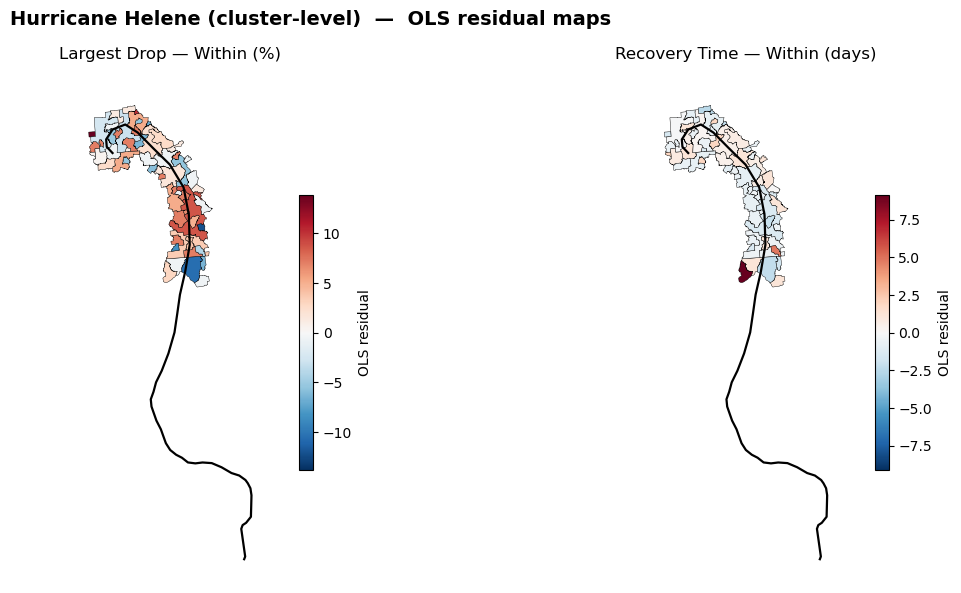

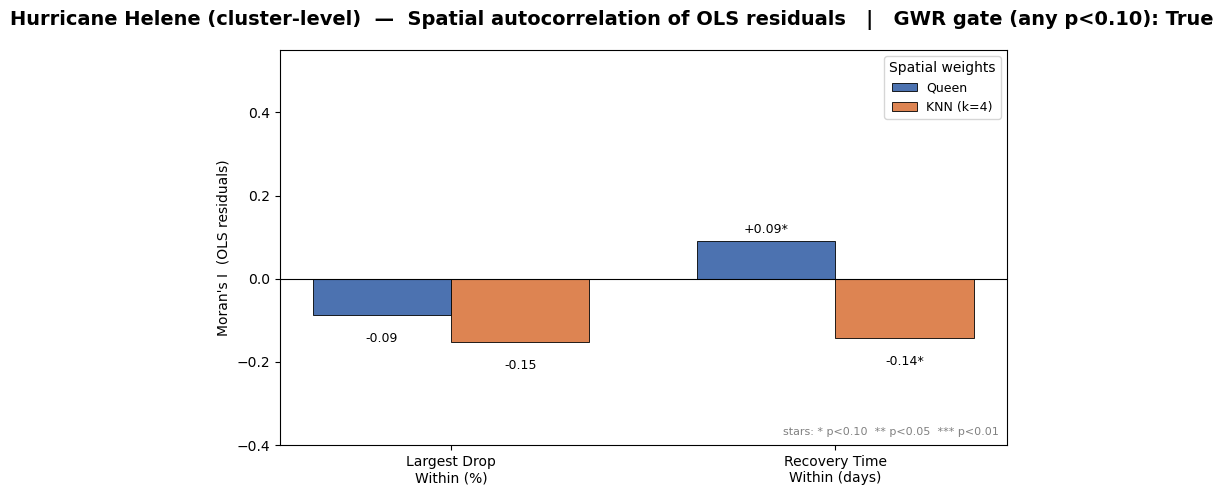

In [5]:
_ = U.plot_residual_maps(g, ols, track, HURR)      # Fig 1
_ = U.plot_morans(diag, HURR)                       # Fig 2

## §4  Geographically Weighted Regression
Adaptive bisquare kernel; bandwidth chosen by AICc. Bounds are set explicitly because mgwr's default lower bound (40 + 2·k) exceeds these small N.

In [6]:
gwr, bw_bounds = U.fit_gwr(g, X_z)
print('Bandwidth search bounds (k neighbours):', bw_bounds)
for dv, lab in U.DVS:
    r = gwr[dv]
    if r['ok']:
        m = r['model']
        print(f"  {lab:<32} bw={r['bw']:>4}  R2={m.R2:.3f}  adjR2={m.adj_R2:.3f}  "
              f"localR2=[{m.localR2.min():.2f}, {m.localR2.max():.2f}]")
    else:
        print(f'  {lab}: GWR failed -> {r.get("err")}')

Bandwidth search bounds (k neighbours): (8, 37)
  Largest Drop — Within (%)        bw=36.0  R2=0.395  adjR2=0.228  localR2=[0.17, 0.51]
  Recovery Time — Within (days)    bw=33.0  R2=0.505  adjR2=0.348  localR2=[0.29, 0.53]


## §5  GWR maps — local R² and per-predictor t-stats
Local R² (viridis, fixed 0–1) shows where the model explains local variance. The t-stat panels show where each predictor's *local* slope is significant (|t|>1.96); grey = not significant.

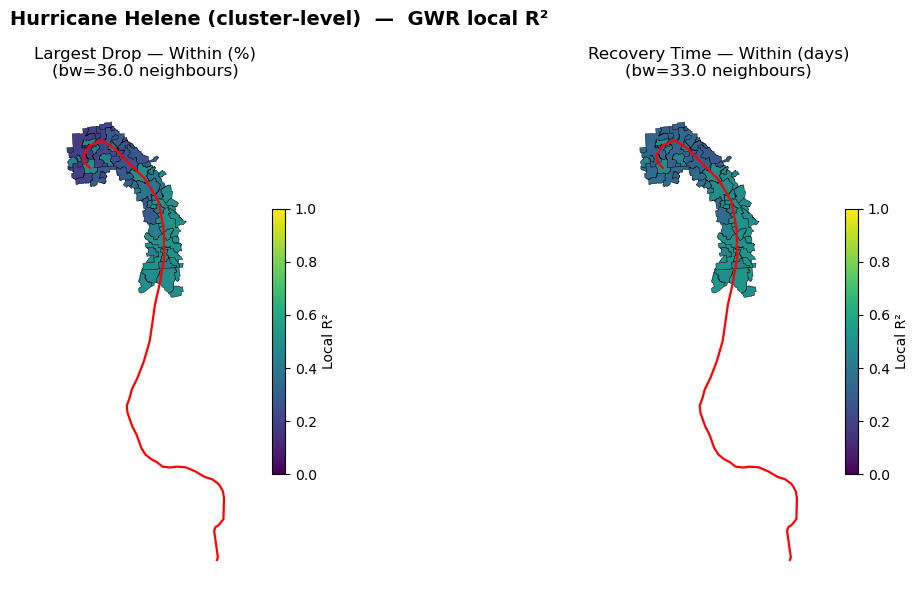

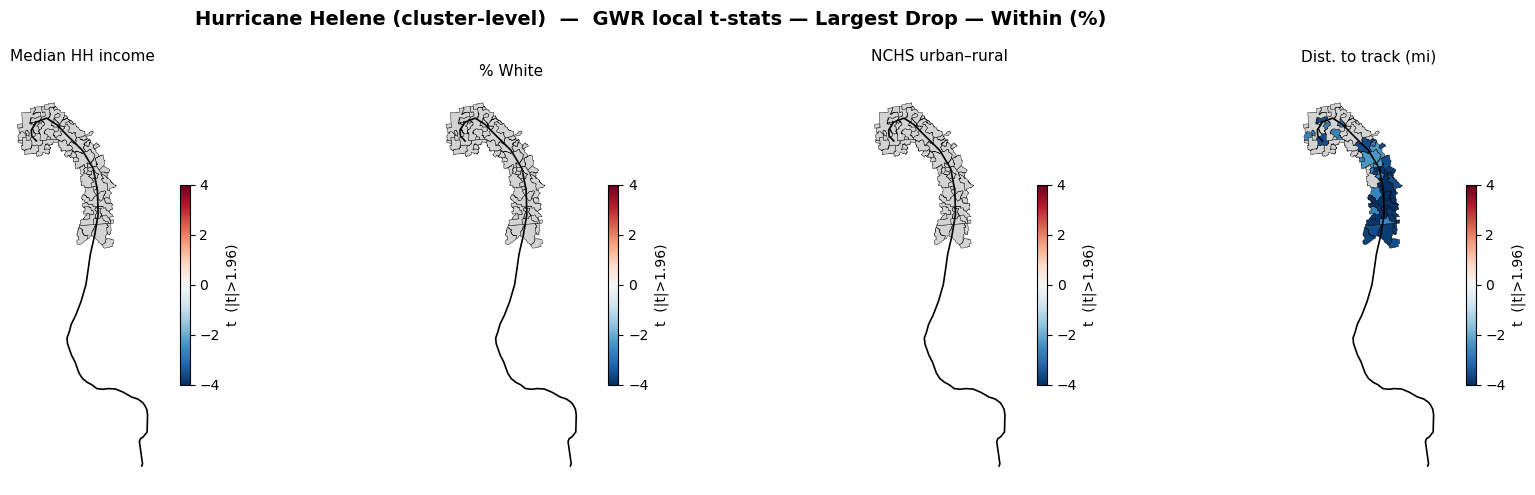

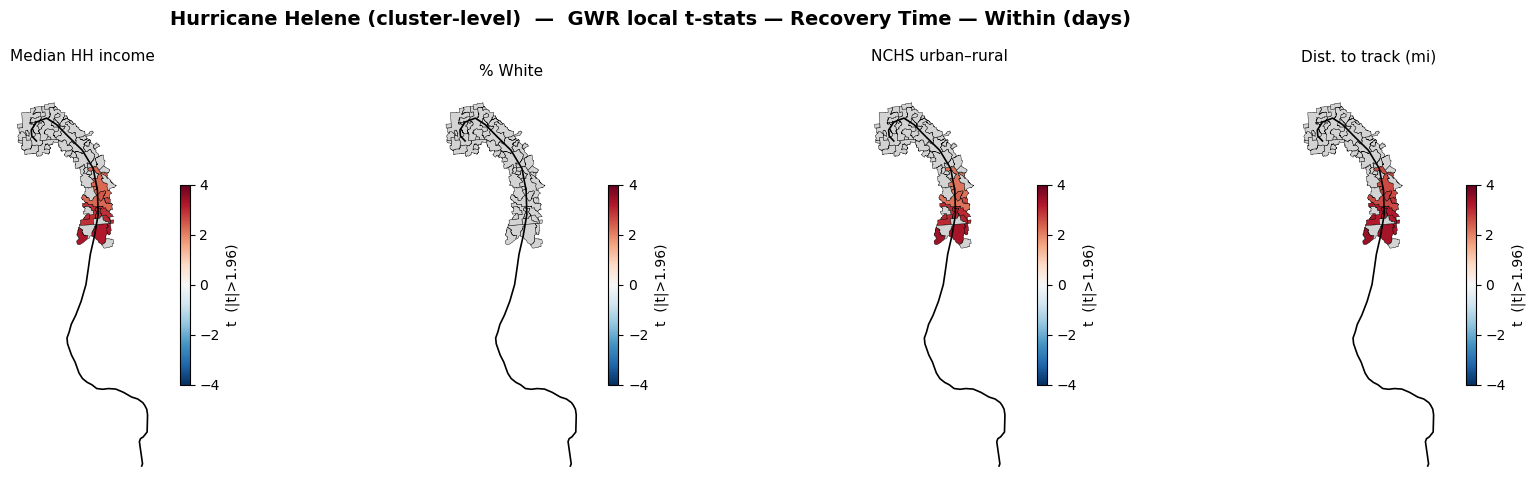

In [7]:
_ = U.plot_local_r2(g, gwr, track, HURR)            # Fig 3
for dv, lab in U.DVS:
    _ = U.plot_coef_tmaps(g, gwr, track, HURR, dv, lab)   # Fig 4 (one per DV)

## §6  OLS vs GWR — does the local model actually help?
AICc on a common scale (statsmodels full Gaussian AIC + small-sample correction, matching mgwr's `aicc`). Lower AICc wins; a negative `dAICc` means GWR beats OLS.

In [8]:
cmp = U.model_comparison(g, ols, gwr)
cmp

,dv,N,OLS_AICc,OLS_R2,OLS_adjR2,GWR_AICc,GWR_R2,GWR_adjR2,GWR_bw,dAICc
0,Largest Drop — Within (%),38,250.66,0.164,0.062,250.89,0.395,0.228,36.0,0.23
1,Recovery Time — Within (days),38,175.63,0.181,0.081,172.34,0.505,0.348,33.0,-3.29


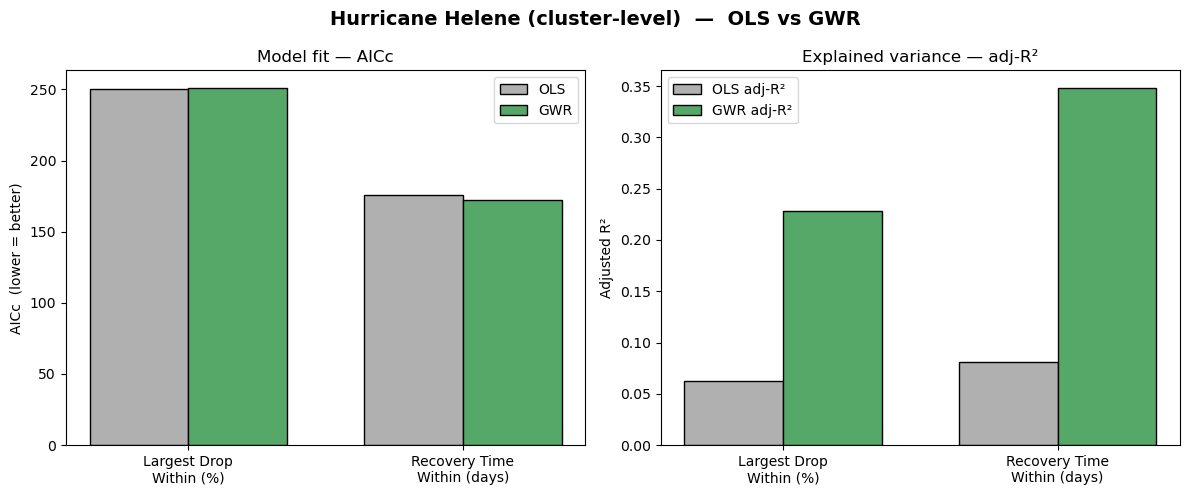

In [9]:
_ = U.plot_model_comparison(cmp, HURR)              # Fig 5

## §7  Interpretation

1. **Moran's I (Fig 2).** Residual spatial autocorrelation is *weak and mostly negative* (Queen I ≈ −0.09 / +0.09; only the KNN(k=4) bars reach p<0.10). After conditioning on income, %White, NCHS and distance-to-track, what the global model misses is **not** strongly clustered in space.

2. **GWR vs OLS (Fig 5).** For *Largest Drop* the global OLS is preferred (ΔAICc = +0.23 — GWR's extra effective parameters do not pay for themselves). For *Recovery Time* GWR is modestly better (ΔAICc = −3.29), and the local-R² map (Fig 3) shows the model fits best along the eastern limb of the track.

3. **Verdict.** Limited but non-zero spatial nonstationarity. Recovery-time drivers vary mildly across the footprint; drop magnitude is essentially a stationary (global) process at this resolution.

---
*Figures saved to* `results/gwr_compare/helene/figures/` *(fig1–fig5). Compare against the [Milton notebook](milton_gwr_compare.ipynb) panel-for-panel.*